In [ ]:
%pip install roboflow
%pip install ultralytics

In [ ]:
import roboflow
from google.colab import userdata
RF_API_KEY = userdata.get('RF_API_KEY')
rf = roboflow.Roboflow(api_key=RF_API_KEY)
project = rf.workspace().project("v1-caretech-combined-dataset-a6u4l")
dataset = project.version(1).download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to [V1]-CareTech-Combined-Dataset-1 in yolo26:: 100%|██████████| 99259/99259 [00:31<00:00, 3161.36it/s]


In [ ]:
!mv "/content/[V1]-CareTech-Combined-Dataset-1" "/content/V1-CareTech-Combined-Dataset-1"


In [ ]:
from pathlib import Path
from collections import Counter

label_dir = Path("/content/V1-CareTech-Combined-Dataset-1")
class_counts = Counter()

for label_file in label_dir.rglob('*.txt'):
    with open(label_file, 'r') as f:
        for line in f:
            parts = line.split()
            if parts:
                try:
                  class_id = int(parts[0])
                  class_counts[class_id] += 1
                except ValueError:
                  pass

# Display results
for cls_id in sorted(class_counts.keys()):
    print(f"{cls_id:8} | {class_counts[cls_id]}")

       0 | 206
       1 | 188
       2 | 106
       3 | 180
       4 | 193
       5 | 174
       6 | 183
       7 | 176
       8 | 181
       9 | 182
      10 | 183
      11 | 182
      12 | 178
      13 | 215
      14 | 306
      15 | 179
      16 | 184
      17 | 199
      18 | 162
      19 | 175
      20 | 174
      21 | 188
      22 | 200
      23 | 192
      24 | 183
      25 | 179
      26 | 179
      27 | 176
      28 | 179
      29 | 191
      30 | 190
      31 | 148
      32 | 173
      33 | 143
      34 | 171
      35 | 192
      36 | 173
      37 | 226
      38 | 190
      39 | 170
      40 | 197
      41 | 195
      42 | 192
      43 | 186
      44 | 186
      45 | 206
      46 | 171
      47 | 183
      48 | 168
      49 | 156
      50 | 186
      51 | 188
      52 | 192
      53 | 168
      54 | 231
      55 | 177
      56 | 185
      57 | 220
      58 | 196
      59 | 190
      60 | 166
      61 | 173
      62 | 176
      63 | 198
      64 | 189
      65 | 368
      66 |

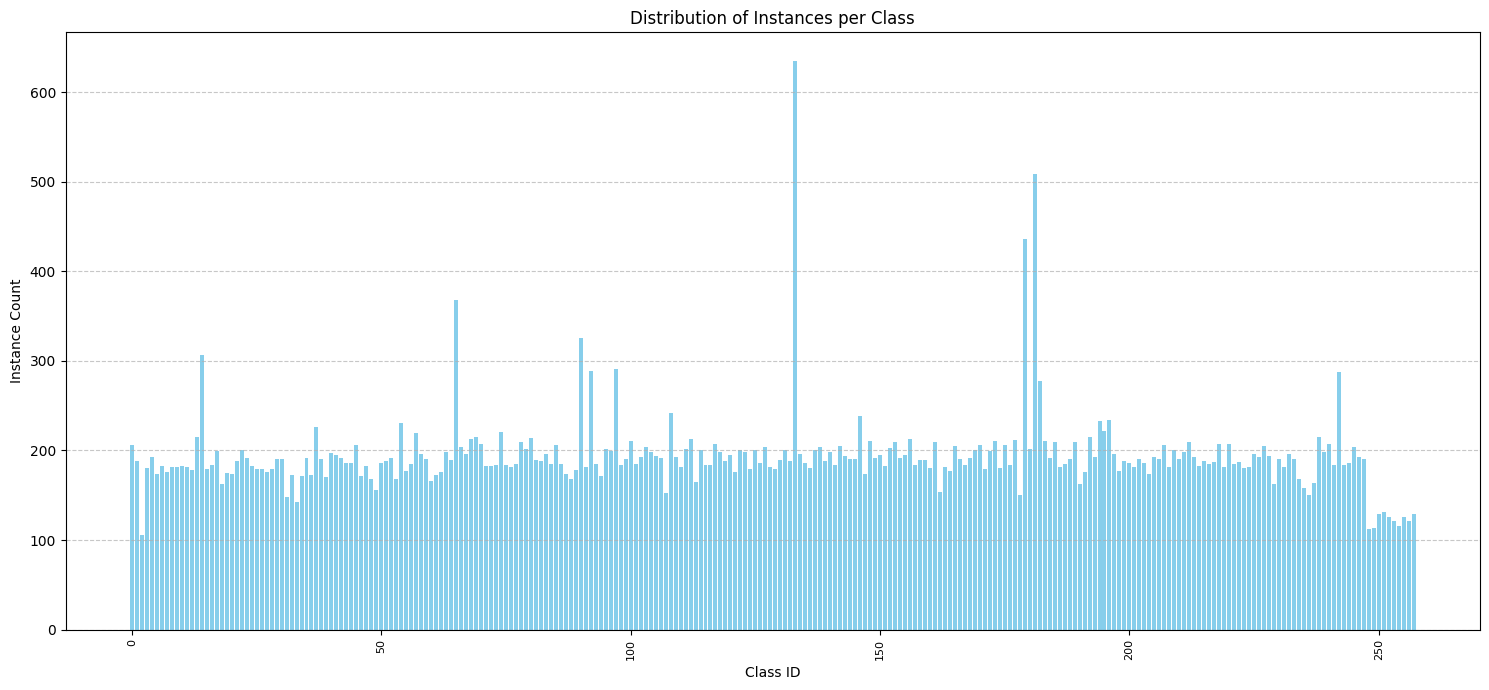

In [ ]:
import matplotlib.pyplot as plt

# Prepare data for plotting
class_ids = sorted(class_counts.keys())
counts = [class_counts[cls_id] for cls_id in class_ids]

# Create the bar plot
plt.figure(figsize=(15, 7))
plt.bar(class_ids, counts, color='skyblue')
plt.xlabel('Class ID')
plt.ylabel('Instance Count')
plt.title('Distribution of Instances per Class')
plt.xticks(rotation=90, fontsize=8) # Rotate x-axis labels for better readability if many classes
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [ ]:
from pathlib import Path

base_dir = Path("/content/V1-CareTech-Combined-Dataset-1")

image_to_label_paths = {}

image_extensions = ['jpg', 'jpeg', 'png']

for ext in image_extensions:
    for image_path in base_dir.rglob(f'*.{ext}'):
        label_path_parts = list(image_path.parts)
        try:
            images_index = label_path_parts.index('images')
            label_path_parts[images_index] = 'labels'
            label_path = Path(*label_path_parts).with_suffix('.txt')

            if label_path.exists():
                image_to_label_paths[str(image_path)] = str(label_path)
        except ValueError: # 'images' not found in path, skip this path if it's not in the expected structure
            continue


In [ ]:
from collections import defaultdict
from pathlib import Path

class_to_image_paths = defaultdict(list)

# Iterate through the image_to_label_paths mapping
for image_path_str, label_path_str in image_to_label_paths.items():
    label_path = Path(label_path_str)

    try:
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_id = int(parts[0])
                    class_to_image_paths[class_id].append(image_path_str)
    except FileNotFoundError:
        print(f"Warning: Label file not found for {image_path_str} at {label_path_str}. Skipping.")
    except ValueError:
        print(f"Warning: Could not parse class ID from line in {label_path_str}. Skipping line.")

for class_id in class_to_image_paths:
    class_to_image_paths[class_id] = list(set(class_to_image_paths[class_id]))

print("Number of images per class (unique images):")
for class_id in sorted(class_to_image_paths.keys()):
    print(f"Class {class_id}: {len(class_to_image_paths[class_id])} images")


Number of images per class (unique images):
Class 0: 206 images
Class 1: 188 images
Class 2: 49 images
Class 3: 180 images
Class 4: 193 images
Class 5: 174 images
Class 6: 183 images
Class 7: 176 images
Class 8: 181 images
Class 9: 182 images
Class 10: 183 images
Class 11: 182 images
Class 12: 178 images
Class 13: 210 images
Class 14: 301 images
Class 15: 179 images
Class 16: 184 images
Class 17: 199 images
Class 18: 162 images
Class 19: 175 images
Class 20: 174 images
Class 21: 188 images
Class 22: 200 images
Class 23: 192 images
Class 24: 183 images
Class 25: 179 images
Class 26: 179 images
Class 27: 176 images
Class 28: 179 images
Class 29: 191 images
Class 30: 190 images
Class 31: 148 images
Class 32: 173 images
Class 33: 143 images
Class 34: 171 images
Class 35: 192 images
Class 36: 173 images
Class 37: 221 images
Class 38: 177 images
Class 39: 170 images
Class 40: 197 images
Class 41: 195 images
Class 42: 192 images
Class 43: 186 images
Class 44: 186 images
Class 45: 205 images
C

In [ ]:
import random

images_to_remove = set()

for class_id, image_paths in class_to_image_paths.items():
    num_images_to_remove = int(len(image_paths) * 0.10)

    if num_images_to_remove > len(image_paths):
        num_images_to_remove = len(image_paths)

    selected_images = random.sample(image_paths, num_images_to_remove)

    images_to_remove.update(selected_images)

print(f"Total unique images identified for removal: {len(images_to_remove)}")

Total unique images identified for removal: 4851


In [ ]:
import os

for image_path_str in images_to_remove:
    try:
        label_path_str = image_to_label_paths.get(image_path_str)

        if label_path_str:
            os.remove(image_path_str)
            os.remove(label_path_str)
        else:
            print(f"Warning: No corresponding label path found for image: {image_path_str}. Skipping label deletion.")

    except FileNotFoundError:
        print(f"Warning: File not found for either {image_path_str} or its label. It might have been deleted already or never existed.")
    except Exception as e:
        print(f"An unexpected error occurred while deleting files: {e}")

print(f"Finished attempting to delete {len(images_to_remove)} image-label pairs.")

Finished attempting to delete 4851 image-label pairs.


In [ ]:
from pathlib import Path
from collections import Counter

label_dir = Path("/content/V1-CareTech-Combined-Dataset-1")
class_counts = Counter()

for label_file in label_dir.rglob('*.txt'):
    with open(label_file, 'r') as f:
        for line in f:
            parts = line.split()
            if parts:
                try:
                  class_id = int(parts[0])
                  class_counts[class_id] += 1
                except ValueError:
                  pass


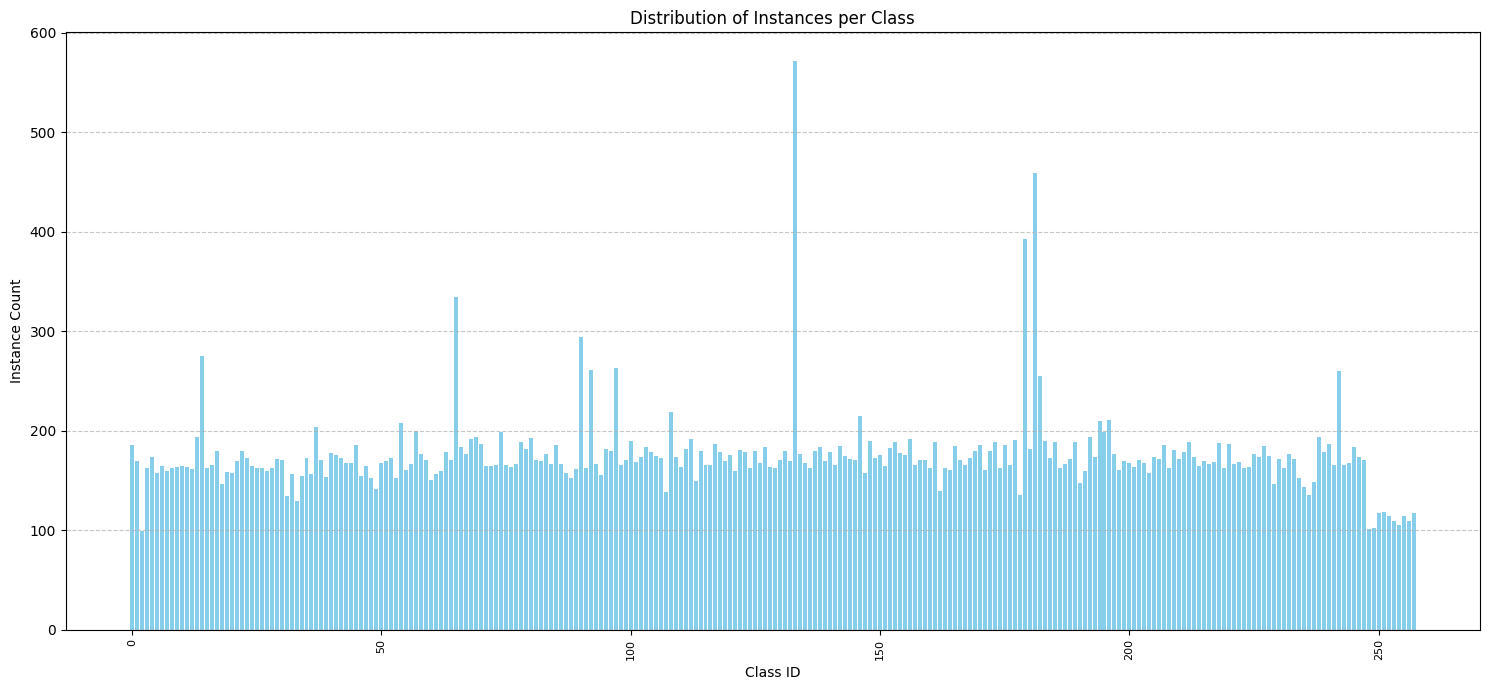

In [ ]:
import matplotlib.pyplot as plt

# Prepare data for plotting
class_ids = sorted(class_counts.keys())
counts = [class_counts[cls_id] for cls_id in class_ids]

# Create the bar plot
plt.figure(figsize=(15, 7))
plt.bar(class_ids, counts, color='skyblue')
plt.xlabel('Class ID')
plt.ylabel('Instance Count')
plt.title('Distribution of Instances per Class')
plt.xticks(rotation=90, fontsize=8) # Rotate x-axis labels for better readability if many classes
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [ ]:
from roboflow import Roboflow
from google.colab import userdata
RF_API_KEY = userdata.get('RF_API_KEY')
rf = Roboflow(api_key=RF_API_KEY)

new_project = rf.workspace().create_project(
    project_name="ablation_dataset",
    project_license="MIT",
    project_type="object-detection",
    annotation="1"
)

"""
Parameters:
- project_name: Preferred project name.
- project_type: Must be one of object-detection, single-label-classification, multi-label-classification, instance-segmentation, or semantic-segmentation.
- project_description: Preferred project description.
"""


loading Roboflow workspace...


'\nParameters:\n- project_name: Preferred project name.\n- project_type: Must be one of object-detection, single-label-classification, multi-label-classification, instance-segmentation, or semantic-segmentation.\n- project_description: Preferred project description.\n'

In [ ]:
!roboflow login

visit https://app.roboflow.com/auth-cli to get your authentication token.
Paste the authentication token here: 


In [ ]:
!roboflow import -w ctworkspacedavid -p ablation-dataset /content/V1-CareTech-Combined-Dataset-1/

Streaming output truncated to the last 5000 lines.
[UPLOADED] /content/V1-CareTech-Combined-Dataset-1/valid/images/beef_bowl_012426_jpg.rf.0ed39a14d10618e6c861193e2121b36f.jpg (mlZOEZ8XQIVQSNgJWChP) [0.8s] / annotations = OK [0.3s]
[UPLOADED] /content/V1-CareTech-Combined-Dataset-1/valid/images/beef_bowl_012433_jpg.rf.b06bf06ea8e55f505cc243259cccbbad.jpg (StylkOtBoRngtRt6pZrz) [0.7s] / annotations = OK [0.3s]
[UPLOADED] /content/V1-CareTech-Combined-Dataset-1/valid/images/beef_bowl_012438_jpg.rf.653e0737ffca6ba41ce5d0193702a7c0.jpg (xNPllbOAs3owCUqdqylB) [0.8s] / annotations = OK [0.3s]
[UPLOADED] /content/V1-CareTech-Combined-Dataset-1/valid/images/beef_bowl_012442_jpg.rf.eea5fbfbd3f536d73dab19daf7fb3b4a.jpg (AK0PyrCaZPHvBgM2v56z) [0.6s] / annotations = OK [0.3s]
[UPLOADED] /content/V1-CareTech-Combined-Dataset-1/valid/images/beef_bowl_012466_jpg.rf.0fdc88ca948e1cd8917058bf585a2d5f.jpg (JJn7IlMfcP6msX5OA2EC) [0.5s] / annotations = OK [0.4s]
[UPLOADED] /content/V1-CareTech-Combined-Dat